Dataset loaded successfully.
Raw dataset shape: (50401, 300)

Raw date range:
First date: 2014-12-31T23:00:00Z
Last date : 2020-09-30T23:00:00Z

Germany-related columns:
DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation

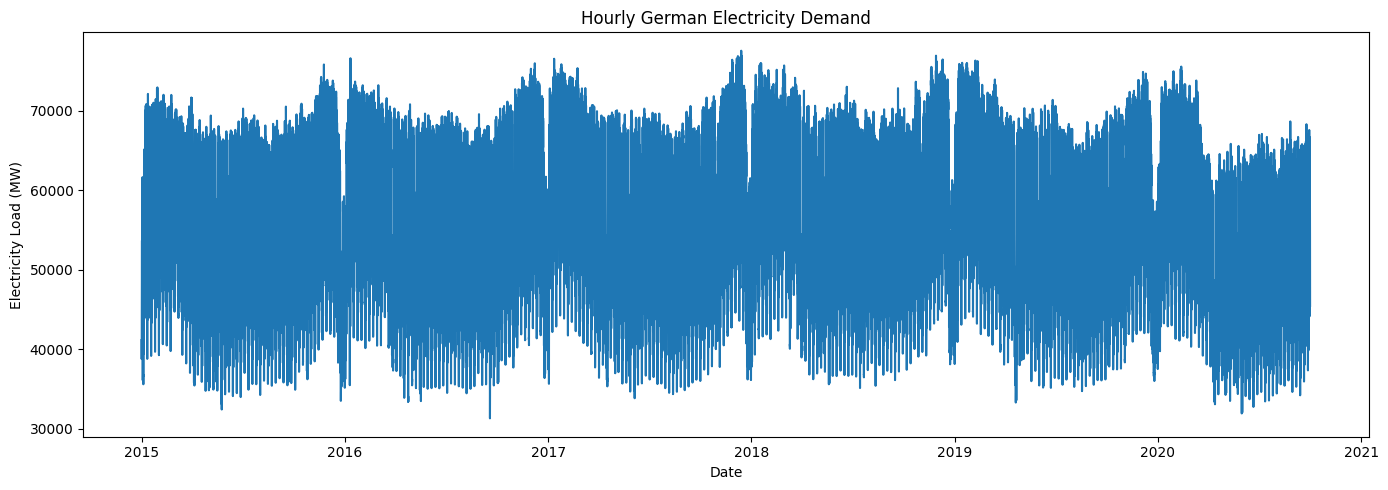

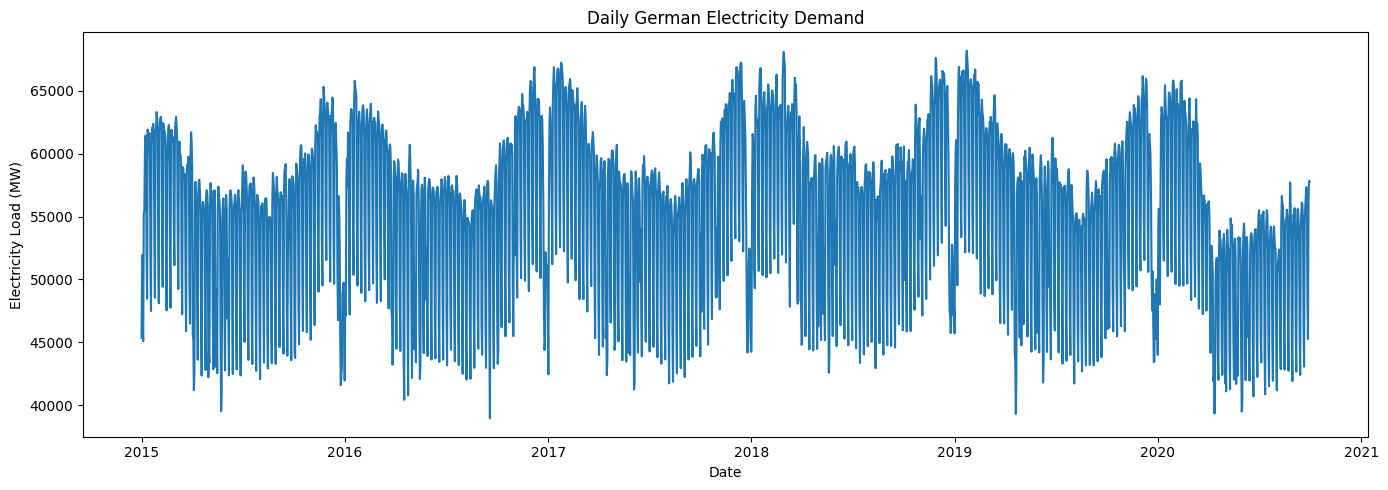

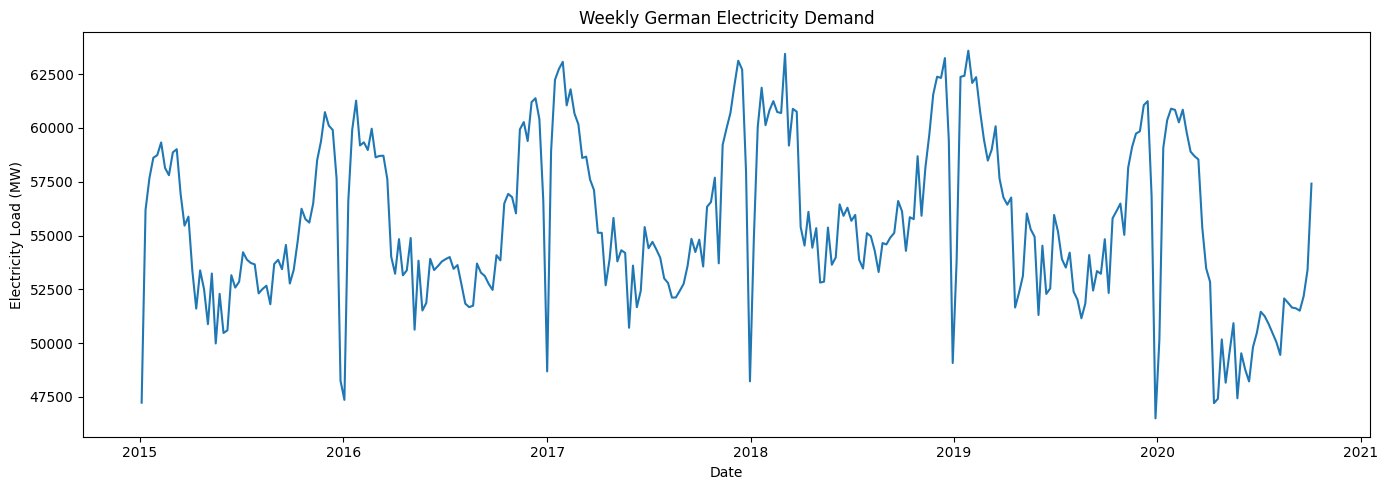


Data cleaning and resampling completed correctly.


In [4]:
# DATA CLEANING AND RESAMPLING FOR GERMAN ELECTRICITY DEMAND


import pandas as pd
import matplotlib.pyplot as plt
import os


# 1. Load the dataset


file_path = "time_series_60min_singleindex.csv"

df_raw = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Raw dataset shape:", df_raw.shape)


# 2. Check date range of raw dataset

print("\nRaw date range:")
print("First date:", df_raw["utc_timestamp"].min())
print("Last date :", df_raw["utc_timestamp"].max())


# 3. Identify Germany demand column


germany_columns = [col for col in df_raw.columns if col.startswith("DE")]

print("\nGermany-related columns:")
for col in germany_columns:
    print(col)

germany_actual_load_columns = [
    col for col in df_raw.columns
    if col.startswith("DE")
    and "load_actual" in col.lower()
]

print("\nPossible German actual load columns:")
print(germany_actual_load_columns)

# Use national Germany demand column
load_column = "DE_load_actual_entsoe_transparency"

if load_column not in df_raw.columns:
    raise ValueError("German national demand column not found. Check column names.")

print("\nSelected German demand column:", load_column)


# 4. Keep only timestamp and German load column


df = df_raw[["utc_timestamp", load_column]].copy()

df.rename(columns={
    "utc_timestamp": "Date",
    load_column: "Load"
}, inplace=True)


# 5. Convert Date to datetime and set index

df["Date"] = pd.to_datetime(df["Date"], utc=True)
df.set_index("Date", inplace=True)


# 6. From 1 Jan 2015 to Oct 2020

df = df.loc["2015-01-01":"2020-10-31"].copy()

print("\nFiltered date range:")
print("First date:", df.index.min())
print("Last date :", df.index.max())


# 7. Sort index


df = df.sort_index()


# 8. Check duplicate timestamps

duplicate_timestamps = df.index.duplicated().sum()
print("\nDuplicate timestamps:", duplicate_timestamps)

if duplicate_timestamps > 0:
    df = df[~df.index.duplicated(keep="first")]


# 9. Check missing values

print("\nMissing values before treatment:")
print(df.isnull().sum())

# Time-based interpolation for continuous time series
df["Load"] = df["Load"].interpolate(method="time")
df["Load"] = df["Load"].ffill()
df["Load"] = df["Load"].bfill()

print("\nMissing values after treatment:")
print(df.isnull().sum())


# 10. Create daily and weekly datasets

daily_load = df.resample("D").mean()
weekly_load = df.resample("W").mean()


# 11. Print final checks


print("\nFinal hourly data:")
print(df.head())
print(df.tail())
print("Hourly shape:", df.shape)

print("\nFinal daily data:")
print(daily_load.head())
print(daily_load.tail())
print("Daily shape:", daily_load.shape)

print("\nFinal weekly data:")
print(weekly_load.head())
print(weekly_load.tail())
print("Weekly shape:", weekly_load.shape)


# 12. Save cleaned data


os.makedirs("processed_data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

df.to_csv("processed_data/hourly_germany_load.csv")
daily_load.to_csv("processed_data/daily_germany_load.csv")
weekly_load.to_csv("processed_data/weekly_germany_load.csv")

print("\nCleaned datasets saved successfully.")


# 13. Plot hourly, daily and weekly data

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Load"])
plt.title("Hourly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/hourly_german_electricity_demand.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(daily_load.index, daily_load["Load"])
plt.title("Daily German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/daily_german_electricity_demand.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(weekly_load.index, weekly_load["Load"])
plt.title("Weekly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.savefig("figures/weekly_german_electricity_demand.png", dpi=300)
plt.show()

print("\nData cleaning and resampling completed correctly.")